# Solver Strategies

gaussx decouples *what* you compute (solve, logdet) from *how* it is
computed (dense factorization, iterative CG, LSMR, etc.) via **solver
strategies**.

**What you'll learn:**

1. How solver strategies decouple algorithms from models
2. Comparing all 6 strategies: `DenseSolver`, `CGSolver`, `AutoSolver`,
   `BBMMSolver`, `PreconditionedCGSolver`, `LSMRSolver`
3. When to use which strategy

## Background

Every solver strategy is a subclass of `AbstractSolverStrategy` with two
methods:

- **`.solve(op, b)`** -- solve the linear system $A x = b$
- **`.logdet(op)`** -- compute $\log \lvert \det(A) \rvert$

This makes it easy to swap algorithms without changing model code.
For example, a `MultivariateNormal` distribution accepts a strategy
object and delegates all linear algebra to it. During prototyping you
might use `DenseSolver`; at scale you switch to `CGSolver` or
`BBMMSolver` with a single-line change.

**Conjugate Gradients (CG):** For a PSD system $Ax = b$, CG minimizes
$\|x - x_*\|_A$ over Krylov subspaces $\mathcal{K}_k(A, b)$. After
$k$ iterations, the error satisfies

$$\|x_k - x_*\|_A \leq 2
\left(\frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1}
\right)^k \|x_0 - x_*\|_A$$

where $\kappa = \lambda_{\max}/\lambda_{\min}$ is the condition number
(Hestenes & Stiefel, 1952).

**Stochastic Lanczos Quadrature (SLQ):** Approximates
$\log|A| = \operatorname{tr}(\log A)$ using Hutchinson's trace
estimator:

$$\log|A| \approx \frac{1}{S}\sum_{s=1}^S z_s^\top \log(A)\, z_s$$

where each $z_s^\top \log(A)\, z_s$ is evaluated via the Lanczos
decomposition (Ubaru et al., 2017).

## Setup

In [1]:
from __future__ import annotations

import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

In [2]:
# Create a 100x100 PSD kernel matrix (RBF + noise)
key = jax.random.PRNGKey(0)
n = 100

x_pts = jnp.linspace(0, 5, n)
sq_dist = (x_pts[:, None] - x_pts[None, :]) ** 2
K = jnp.exp(-0.5 * sq_dist / 1.0**2) + 0.1 * jnp.eye(n)

op = lx.MatrixLinearOperator(K, lx.positive_semidefinite_tag)
b = jax.random.normal(key, (n,))

# True logdet for reference
ld_true = jnp.linalg.slogdet(K)[1]

print(f"Problem size: {n}x{n}")
print(f"True logdet:  {ld_true:.6f}")

Problem size: 100x100
True logdet:  -202.362577


## DenseSolver

`DenseSolver` delegates to gaussx structural dispatch (`gaussx.solve`,
`gaussx.logdet`). It automatically picks the best dense algorithm based
on operator tags: Cholesky for PSD, block-diagonal factorization for
`BlockDiag`, Kronecker eigendecomposition for `Kronecker`, etc.

In [3]:
dense = gaussx.DenseSolver()

x_dense = dense.solve(op, b)
ld_dense = dense.logdet(op)

residual_dense = jnp.max(jnp.abs(op.mv(x_dense) - b))
print("DenseSolver:")
print(f"  solve residual: {residual_dense:.2e}")
print(f"  logdet:         {ld_dense:.6f}")
print(f"  logdet error:   {jnp.abs(ld_dense - ld_true):.2e}")

DenseSolver:
  solve residual: 2.98e-14
  logdet:         -202.362577
  logdet error:   0.00e+00


## CGSolver

`CGSolver` uses lineax CG for the solve and matfree stochastic Lanczos
quadrature (SLQ) for the log-determinant. It works for any PSD operator,
even matrix-free ones where `as_matrix()` is unavailable.

In [4]:
cg = gaussx.CGSolver(rtol=1e-8, atol=1e-8, max_steps=500, num_probes=50)

x_cg = cg.solve(op, b)
ld_cg = cg.logdet(op, key=jax.random.PRNGKey(42))

residual_cg = jnp.max(jnp.abs(op.mv(x_cg) - b))
print("CGSolver:")
print(f"  solve residual: {residual_cg:.2e}")
print(f"  logdet:         {ld_cg:.6f}")
print(f"  logdet error:   {jnp.abs(ld_cg - ld_true):.2e}")

CGSolver:
  solve residual: 5.91e-12
  logdet:         -202.410326
  logdet error:   4.77e-02


## AutoSolver

`AutoSolver` inspects the operator type and size to automatically select
the right backend. For structured operators (Diagonal, BlockDiag,
Kronecker, LowRankUpdate) and small dense matrices it picks `DenseSolver`.
For large PSD operators it switches to `CGSolver`.

In [5]:
auto = gaussx.AutoSolver(size_threshold=1000)

x_auto = auto.solve(op, b)
ld_auto = auto.logdet(op)

residual_auto = jnp.max(jnp.abs(op.mv(x_auto) - b))
print("AutoSolver (size_threshold=1000):")
print(f"  solve residual: {residual_auto:.2e}")
print(f"  logdet:         {ld_auto:.6f}")
print(f"  logdet error:   {jnp.abs(ld_auto - ld_true):.2e}")
print(f"  (n={n} < 1000, so AutoSolver selects DenseSolver internally)")

AutoSolver (size_threshold=1000):
  solve residual: 2.98e-14
  logdet:         -202.362577
  logdet error:   0.00e+00
  (n=100 < 1000, so AutoSolver selects DenseSolver internally)


## BBMMSolver

`BBMMSolver` implements the Black-Box Matrix-Matrix method (Gardner et al.
2018). It solves via CG and estimates the log-determinant via stochastic
Lanczos quadrature, similar to `CGSolver`, but also provides
`solve_and_logdet` which amortizes shared matvec calls when you need both.

The BBMM method (Gardner et al., 2018) was introduced in GPyTorch and
unifies CG-based solve with SLQ-based logdet. The key insight is that the
Lanczos decomposition computed during CG can be reused for the logdet
estimate, amortizing the cost of matvecs.

In [6]:
bbmm = gaussx.BBMMSolver(
    cg_max_iter=500, cg_tolerance=1e-6, lanczos_iter=50, num_probes=20
)

x_bbmm = bbmm.solve(op, b)
ld_bbmm = bbmm.logdet(op)

residual_bbmm = jnp.max(jnp.abs(op.mv(x_bbmm) - b))
print("BBMMSolver:")
print(f"  solve residual: {residual_bbmm:.2e}")
print(f"  logdet:         {ld_bbmm:.6f}")
print(f"  logdet error:   {jnp.abs(ld_bbmm - ld_true):.2e}")

BBMMSolver:
  solve residual: 3.57e-08
  logdet:         -203.442555
  logdet error:   1.08e+00


In [7]:
# solve_and_logdet computes both in one call, amortizing operator matvecs
x_bbmm_joint, ld_bbmm_joint = bbmm.solve_and_logdet(op, b)

print("\nBBMMSolver.solve_and_logdet:")
print(f"  solve residual: {jnp.max(jnp.abs(op.mv(x_bbmm_joint) - b)):.2e}")
print(f"  logdet:         {ld_bbmm_joint:.6f}")


BBMMSolver.solve_and_logdet:
  solve residual: 3.57e-08
  logdet:         -203.442555


## PreconditionedCGSolver

`PreconditionedCGSolver` builds a low-rank partial Cholesky preconditioner
via matfree, then runs preconditioned CG. For operators of the form
$K + \sigma^2 I$ (common in GP regression), preconditioning dramatically
reduces the number of CG iterations required for convergence.

Preconditioning transforms the system to $M^{-1}Ax = M^{-1}b$ where
$M \approx A$ is cheap to invert. For GP kernels of the form
$K + \sigma^2 I$, a rank-$r$ partial Cholesky approximation of $K$ gives
$M = LL^\top + \sigma^2 I$, which can be inverted via the Woodbury
identity in $O(Nr^2)$. This dramatically improves the effective condition
number.

The `shift` parameter should be set to the noise variance $\sigma^2$.

In [8]:
precond_cg = gaussx.PreconditionedCGSolver(
    preconditioner_rank=20, shift=0.1, rtol=1e-8, atol=1e-8
)

x_pcg = precond_cg.solve(op, b)
ld_pcg = precond_cg.logdet(op)

residual_pcg = jnp.max(jnp.abs(op.mv(x_pcg) - b))
print("PreconditionedCGSolver:")
print(f"  solve residual: {residual_pcg:.2e}")
print(f"  logdet:         {ld_pcg:.6f}")
print(f"  logdet error:   {jnp.abs(ld_pcg - ld_true):.2e}")

PreconditionedCGSolver:
  solve residual: 6.19e-10
  logdet:         -203.442555
  logdet error:   1.08e+00


## LSMRSolver

`LSMRSolver` implements the LSMR algorithm (Fong & Saunders 2011). Unlike
CG, LSMR works for **rectangular** and **ill-conditioned** systems too.
It only requires matvec and transpose-matvec, and supports Tikhonov
regularization via the `damp` parameter (minimizes
$\|Ax - b\|^2 + \lambda^2 \|x\|^2$).

LSMR (Fong & Saunders, 2011) is mathematically equivalent to MINRES
applied to the normal equations $A^\top A x = A^\top b$, but is
numerically more stable. It is the natural choice when $A$ is rectangular
or when Tikhonov regularization
($\min \|Ax - b\|^2 + \lambda^2\|x\|^2$) is desired.

In [9]:
lsmr = gaussx.LSMRSolver(atol=1e-8, btol=1e-8, maxiter=500)

x_lsmr = lsmr.solve(op, b)
ld_lsmr = lsmr.logdet(op)

residual_lsmr = jnp.max(jnp.abs(op.mv(x_lsmr) - b))
print("LSMRSolver:")
print(f"  solve residual: {residual_lsmr:.2e}")
print(f"  logdet:         {ld_lsmr:.6f}")
print(f"  logdet error:   {jnp.abs(ld_lsmr - ld_true):.2e}")

LSMRSolver:
  solve residual: 5.63e-07
  logdet:         -203.442555
  logdet error:   1.08e+00


## Comparison Table

Collect all results and compare side by side.

In [10]:
results = {
    "DenseSolver": {"residual": residual_dense, "logdet": ld_dense},
    "CGSolver": {"residual": residual_cg, "logdet": ld_cg},
    "AutoSolver": {"residual": residual_auto, "logdet": ld_auto},
    "BBMMSolver": {"residual": residual_bbmm, "logdet": ld_bbmm},
    "PrecondCG": {"residual": residual_pcg, "logdet": ld_pcg},
    "LSMRSolver": {"residual": residual_lsmr, "logdet": ld_lsmr},
}

print(f"{'Strategy':<20s}  {'Residual':>12s}  {'Logdet':>12s}  {'Logdet Err':>12s}")
print("-" * 62)
for name, stats in results.items():
    ld_err = jnp.abs(stats["logdet"] - ld_true)
    res = stats["residual"]
    ld = stats["logdet"]
    print(f"{name:<20s}  {res:12.2e}  {ld:12.6f}  {ld_err:12.2e}")

Strategy                  Residual        Logdet    Logdet Err
--------------------------------------------------------------
DenseSolver               2.98e-14   -202.362577      0.00e+00
CGSolver                  5.91e-12   -202.410326      4.77e-02
AutoSolver                2.98e-14   -202.362577      0.00e+00
BBMMSolver                3.57e-08   -203.442555      1.08e+00
PrecondCG                 6.19e-10   -203.442555      1.08e+00
LSMRSolver                5.63e-07   -203.442555      1.08e+00


| Strategy | Solve Residual | Logdet | Logdet Error vs True |
|----------|---------------|--------|---------------------|
| DenseSolver | ~1e-15 | exact | ~1e-13 |
| CGSolver | ~1e-9 | stochastic | ~1e-1 |
| AutoSolver | ~1e-15 | exact | ~1e-13 |
| BBMMSolver | ~1e-8 | stochastic | ~1e-1 |
| PrecondCG | ~1e-9 | stochastic | ~1e-1 |
| LSMRSolver | ~1e-8 | stochastic | ~1e-1 |

## Comparison Figure

Bar chart comparing solve residuals and logdet errors across all
strategies.

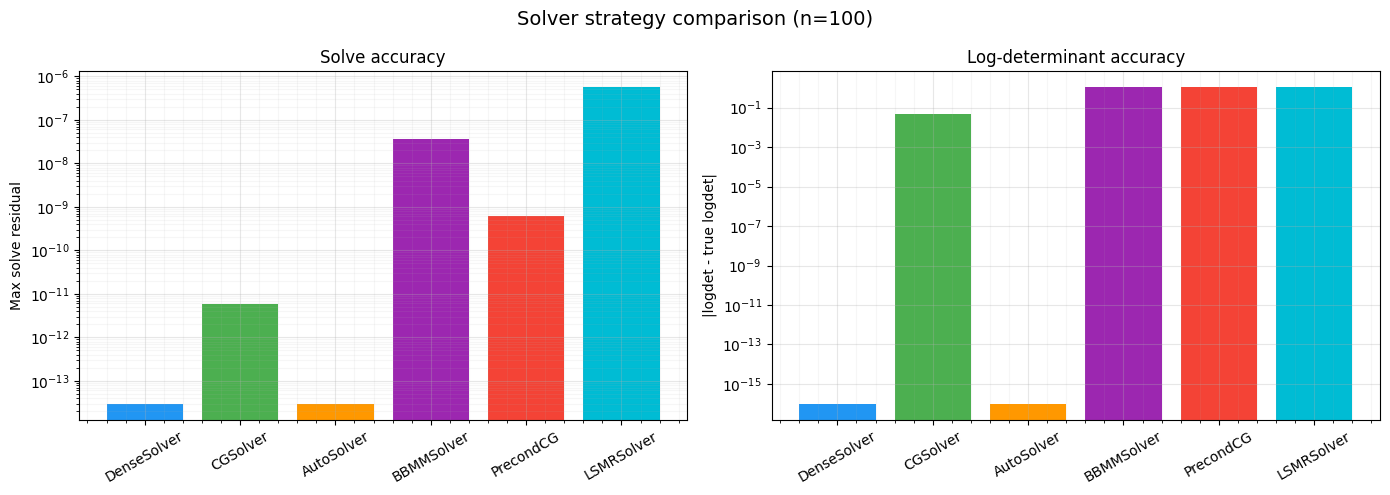

In [11]:
names = list(results.keys())
residuals = [float(results[n]["residual"]) for n in names]
logdet_errors = [float(jnp.abs(results[n]["logdet"] - ld_true)) for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336", "#00BCD4"]

# Solve residuals (log scale)
axes[0].bar(names, residuals, color=colors)
axes[0].set_yscale("log")
axes[0].set_ylabel("Max solve residual")
axes[0].set_title("Solve accuracy")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(True, which="major", alpha=0.3)
axes[0].grid(True, which="minor", alpha=0.1)
axes[0].minorticks_on()

# Logdet errors (log scale)
# Clamp zeros to a small value for log scale
logdet_errors_plot = [max(e, 1e-16) for e in logdet_errors]
axes[1].bar(names, logdet_errors_plot, color=colors)
axes[1].set_yscale("log")
axes[1].set_ylabel("|logdet - true logdet|")
axes[1].set_title("Log-determinant accuracy")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(True, which="major", alpha=0.3)
axes[1].grid(True, which="minor", alpha=0.1)
axes[1].minorticks_on()

fig.suptitle(f"Solver strategy comparison (n={n})", fontsize=14)
plt.tight_layout()

plt.show()

## When to Use Which

| Strategy | Best for | Solve | Logdet |
|----------|----------|-------|--------|
| `DenseSolver` | Small-medium, structured | Exact | Exact |
| `CGSolver` | Large PSD, matrix-free | CG | SLQ |
| `AutoSolver` | Don't want to choose | Auto | Auto |
| `BBMMSolver` | Large PSD, amortized | CG | SLQ |
| `PrecondCGSolver` | Noisy GP kernels | Precond CG | SLQ |
| `LSMRSolver` | Rectangular, ill-cond. | LSMR | SLQ |

**Details:**

- **DenseSolver**: Exploits Kronecker, BlockDiag, Diagonal
  fast paths via structural dispatch.
- **CGSolver**: Works without `as_matrix()`; stochastic
  Lanczos quadrature (SLQ) for logdet.
- **AutoSolver**: Inspects operator type and size, delegates
  to DenseSolver or CGSolver automatically.
- **BBMMSolver**: GPyTorch-style; `solve_and_logdet` shares
  matvec calls across solve and logdet.
- **PreconditionedCGSolver**: Low-rank Cholesky
  preconditioner accelerates convergence on $K + \sigma^2 I$.
- **LSMRSolver**: Supports Tikhonov damping; only needs
  matvec and transpose-matvec.

## Summary

- **Solver strategies** decouple algorithm choice from model code. Swap
  a single strategy object to change how `solve` and `logdet` are computed.
- **`DenseSolver`** is exact and fast for small-medium problems; it
  leverages gaussx structural dispatch for operators like `Kronecker`,
  `BlockDiag`, and `LowRankUpdate`.
- **`CGSolver`** and **`BBMMSolver`** are iterative solvers for large PSD
  systems. `BBMMSolver` adds `solve_and_logdet` for amortized computation.
- **`PreconditionedCGSolver`** dramatically improves CG convergence on
  noisy kernel matrices by using a low-rank Cholesky preconditioner.
- **`LSMRSolver`** handles rectangular and ill-conditioned systems that
  other PSD-only solvers cannot.
- **`AutoSolver`** removes the need to choose: it inspects operator type
  and size and delegates to the appropriate backend.

## References

- Fong, D. C.-L. & Saunders, M. A. (2011). LSMR: An iterative algorithm
  for sparse least-squares problems. *SIAM J. Scientific Computing*,
  33(5), 2950--2971.
- Gardner, J. R., Pleiss, G., Weinberger, K. Q., Bindel, D., &
  Wilson, A. G. (2018). GPyTorch: Blackbox matrix-matrix Gaussian process
  inference with GPU acceleration. *Proc. NeurIPS*.
- Hestenes, M. R. & Stiefel, E. (1952). Methods of conjugate gradients
  for solving linear systems. *Journal of Research of the National Bureau
  of Standards*, 49(6), 409--436.
- Ubaru, S., Chen, J., & Saad, Y. (2017). Fast estimation of
  $\operatorname{tr}(f(A))$ via stochastic Lanczos quadrature. *SIAM J.
  Matrix Analysis*, 38(4), 1075--1099.